# Example-18: Save measured (coupled) twiss as config

In [1]:
# 1. Load uncoupled model
# 2. Generate TbT data and compute parameters (frequencies, amplitudes and phases)
# 3. Compute coupled Twiss parameters from invariant fit
# 4. Compute normalization matrices, add attributes to model and save as coupled

In [2]:
# Import

import numpy
import pandas
import torch

import sys
sys.path.append('..')

from harmonica.util import mod
from harmonica.window import Window
from harmonica.data import Data
from harmonica.frequency import Frequency
from harmonica.filter import Filter
from harmonica.decomposition import Decomposition
from harmonica.model import Model
from harmonica.table import Table
from harmonica.twiss import Twiss

import matplotlib.pyplot as plt

torch.set_printoptions(precision=3, sci_mode=True)
print(torch.cuda.is_available())

True


In [3]:
# Set data type and device

dtype = torch.float64
device = 'cpu'

In [4]:
# Set model with errors

model = Model(path='../config.yaml', model='uncoupled', dtype=dtype, device=device)

# Set errors

model.make_error(1.0E-6, 1.0E-6, length=0.0)

# Set transport

model.make_transport(error=True, exact=False)

# Compute twiss (not used in generation of trajectories)

model.make_twiss()
print(model.is_stable)

# Set fractional tunes

mqx, mqy = model.out_tune_fractional

True


torch.Size([54, 1024, 4])

9.774576086e-08, 1.317029347e-19
4.504085980e-08, 4.652745327e-21



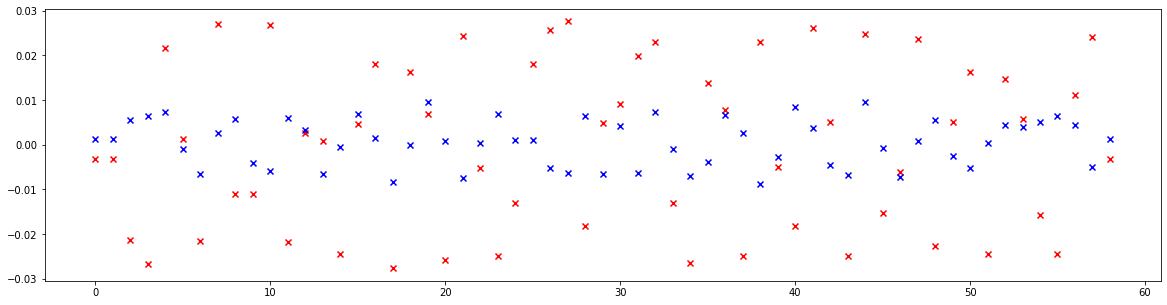

tensor(8.737e-02, dtype=torch.float64)
tensor(3.963e-02, dtype=torch.float64)



In [5]:
# Generate test trajectories

# Set initial condition

initial = torch.tensor([0.001, 0.0, 0.001, 0.0], dtype=dtype, device=device)

# Set number of iterations

length = 2**10

# Generate trajectories

trajectory =  model.make_trajectory(initial, length, error=True, transport=True)[model.monitor_index]
print(trajectory.shape)
print()

# Set x & y coordinates at each monitor location

x = trajectory[..., 0]
y = trajectory[..., 2]

# Compute reference invariant values using selected trajectory

# Set trajectory index

index = 0

# Compute invariants

from harmonica.parameterization import invariant
action_x, action_y = invariant(model.out_normal[model.monitor_index[index]], trajectory[index])

print(f'{action_x.mean().item():>12.9e}, {action_x.std().item():>12.9e}')
print(f'{action_y.mean().item():>12.9e}, {action_y.std().item():>12.9e}')
print()

action_x = action_x.mean()
action_y = action_y.mean()

# Compare model and real beta function values

from harmonica.parameterization import normal_to_wolski
from harmonica.parameterization import wolski_to_cs

cs_ax, cs_bx, cs_ay, cs_by = torch.stack([wolski_to_cs(w) for w in normal_to_wolski(model.out_normal)]).T

plt.figure(figsize=(20, 5))
plt.scatter(range(model.size), 100*(cs_bx - model.bx)/model.bx, color='red', marker='x')
plt.scatter(range(model.size), 100*(cs_by - model.by)/model.by, color='blue', marker='x')
plt.show()

error_x = (cs_bx[model.monitor_index] - model.bx[model.monitor_index]).abs().sum()
error_y = (cs_by[model.monitor_index] - model.by[model.monitor_index]).abs().sum()

print(error_x)
print(error_y)
print()

In [6]:
# Set free normalization matrix elements

N11 = model.out_normal[:, 0, 0][model.monitor_index]
N33 = model.out_normal[:, 2, 2][model.monitor_index]
N21 = model.out_normal[:, 1, 0][model.monitor_index]
N43 = model.out_normal[:, 3, 2][model.monitor_index]
N13 = model.out_normal[:, 0, 2][model.monitor_index]
N31 = model.out_normal[:, 2, 0][model.monitor_index]
N14 = model.out_normal[:, 0, 3][model.monitor_index]
N41 = model.out_normal[:, 3, 0][model.monitor_index]

# Using eight free elements other elements of normalization matrix can be computed from symplectic condition
# Note, N12 and N34 are fixed to zero values

from harmonica.parameterization import parametric_normal
print(torch.allclose(model.out_normal[model.monitor_index], torch.stack([parametric_normal(*free) for free in torch.stack([N11, N33, N21, N43, N13, N31, N14, N41]).T])))

True


In [7]:
# Generate TbT data

# Set noise values for each monitor location 

noise_x = 0.0E-6*(1.0 + 1.0*torch.rand(model.monitor_count, dtype=dtype, device=device))
noise_y = 0.0E-6*(1.0 + 1.0*torch.rand(model.monitor_count, dtype=dtype, device=device))

# Set window

win = Window.from_cosine(length, 1.0, dtype=dtype, device=device)

# Set TbT & add noise

X = Data.from_data(win, x)
X.add_noise(noise_x)
X.data.copy_(X.work)
X.reset()
print(X)

Y = Data.from_data(win, y)
Y.add_noise(noise_y)
Y.data.copy_(Y.work)
Y.reset()
print(Y)

Data(54, Window(1024, 'cosine_window', 1.0))
Data(54, Window(1024, 'cosine_window', 1.0))


In [8]:
# Compute frequency, amplitude and phase for x plane

# Estimate noise

flt = Filter(X)
_, sigma_x = flt.estimate_noise()

# Estimate (main) frequency

f = Frequency(X)
X.window_remove_mean()
X.window_apply()
f('parabola')
X.reset()
nux, sigma_nux = 1.0 - f.frequency.mean(), f.frequency.std()
print(f'mqx={mqx.item():12.9}')
print(f'nux={nux.item():12.9}, sigma_nux={sigma_nux.item():12.9}, error_nux={abs(mqx - nux).item():12.9}')

# Estimate amplitude & phase

d = Decomposition(X)

ax, sigma_ax, _ = d.harmonic_amplitude(nux, length=256, order=1.0, error=True, sigma_frequency=sigma_nux, shift=True, count=64, step=8, method='noise')
fx, sigma_fx, _ = d.harmonic_phase(nux, length=512, order=1.0, error=True, sigma_frequency=sigma_nux, shift=True, count=256, step=8, method='noise')

mqx=  0.53688081
nux=  0.53688081, sigma_nux=1.4525042e-10, error_nux=5.15831822e-12


In [9]:
# Compute frequency, amplitude and phase for y plane

# Estimate noise

flt = Filter(Y)
_, sigma_y = flt.estimate_noise()

# Estimate (main) frequency

f = Frequency(Y)
Y.window_remove_mean()
Y.window_apply()
f('parabola')
Y.reset()
nuy, sigma_nuy = 1.0 - f.frequency.mean(), f.frequency.std()
print(f'mqy={mqy.item():12.9}')
print(f'nuy={nuy.item():12.9}, sigma_nuy={sigma_nuy.item():12.9}, error_nux={abs(mqy - nuy).item():12.9}')

# Estimate amplitude & phase

d = Decomposition(Y)

ay, sigma_ay, _ = d.harmonic_amplitude(nuy, length=256, order=1.0, error=True, sigma_frequency=sigma_nuy, shift=True, count=64, step=8, method='noise')
fy, sigma_fy, _ = d.harmonic_phase(nuy, length=512, order=1.0, error=True, sigma_frequency=sigma_nuy, shift=True, count=256, step=8, method='noise')

mqy= 0.576773077
nuy= 0.576773077, sigma_nuy=1.0451737e-10, error_nux=1.55675473e-12


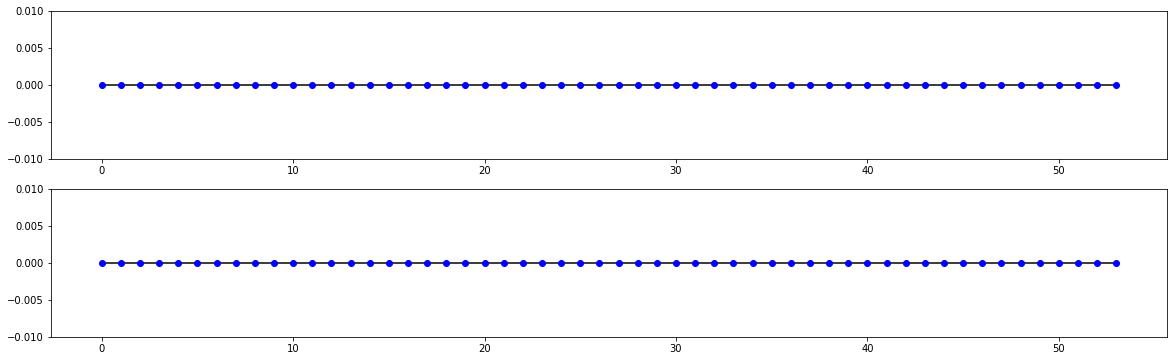

In [10]:
table = Table(
    [name for name, kind in zip(model.name, model.kind) if kind == 'MONITOR'],
    nux, nuy, ax, ay, fx, fy, sigma_nux, sigma_nuy, sigma_ax, sigma_ay, sigma_fx, sigma_fy,
    x=X.data,
    y=Y.data,
    accumulate=True,
    dtype=dtype,
    device=device)

# Compare phase advance between adjacent monitor locations

mux, muy = mod(model.out_advance.roll(1, 0).cumsum(0)[model.monitor_index].T, 2.0*numpy.pi)
mux, _ = Decomposition.phase_adjacent(mqx, mux)
muy, _ = Decomposition.phase_adjacent(mqy, muy)

plt.figure(figsize=(20, 3*2))

ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), (mux - table.phase_x).cpu().numpy(), yerr=table.sigma_x.cpu().numpy(), fmt=' ', marker='o', color='blue')
ax.hlines(0, 0, model.monitor_count - 1, colors='black')
ax.set_ylim(-1.0E-2, +1.0E-2)

ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), (muy - table.phase_y).cpu().numpy(), yerr=table.sigma_y.cpu().numpy(), fmt=' ', marker='o', color='blue')
ax.hlines(0, 0, model.monitor_count - 1, colors='black')
ax.set_ylim(-1.0E-2, +1.0E-2)

plt.show()

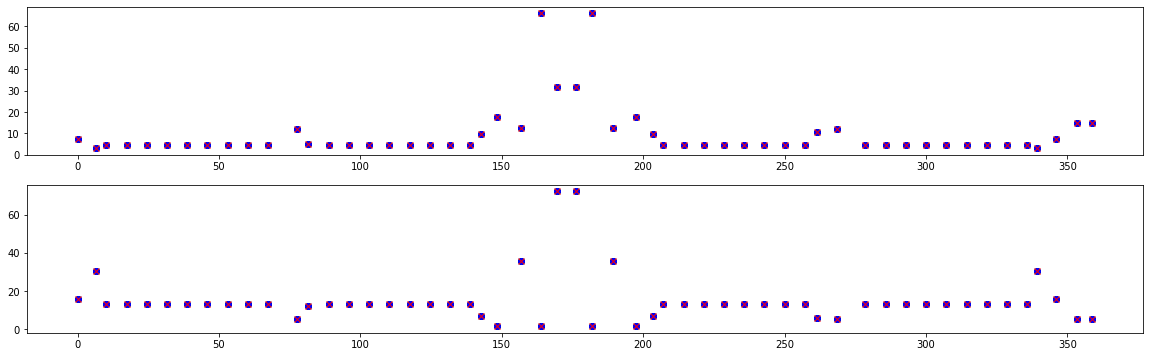

tensor(8.737e-02, dtype=torch.float64)
tensor(5.784e-03, dtype=torch.float64)

tensor(3.963e-02, dtype=torch.float64)
tensor(1.460e-03, dtype=torch.float64)



In [11]:
# Estimate twiss from amplitude

twiss = Twiss(model, table, limit=1)
twiss.get_action()
twiss.get_twiss_from_amplitude()

plt.figure(figsize=(20, 3*2))

ax = plt.subplot(211)
ax.scatter(model.time[model.monitor_index].cpu().numpy(), model.bx[model.monitor_index].cpu().numpy(), marker='o', color='black')
ax.scatter(model.time[model.monitor_index].cpu().numpy(), cs_bx[model.monitor_index].cpu().numpy(), marker='o', color='blue')
ax.errorbar(model.time[model.monitor_index].cpu().numpy(), twiss.data_amplitude['bx'].cpu().numpy(), yerr=twiss.data_amplitude['sigma_bx'].cpu().numpy(), fmt=' ', marker='x', color='red')

ax = plt.subplot(212)
ax.scatter(model.time[model.monitor_index].cpu().numpy(), model.by[model.monitor_index].cpu().numpy(), marker='o', color='black')
ax.scatter(model.time[model.monitor_index].cpu().numpy(), cs_by[model.monitor_index].cpu().numpy(), marker='o', color='blue')
ax.errorbar(model.time[model.monitor_index].cpu().numpy(), twiss.data_amplitude['by'].cpu().numpy(), yerr=twiss.data_amplitude['sigma_by'].cpu().numpy(), fmt=' ', marker='x', color='red')

plt.show()

error_x_1 = (cs_bx[model.monitor_index] - twiss.data_amplitude['bx']).abs().sum()
error_y_1 = (cs_by[model.monitor_index] - twiss.data_amplitude['by']).abs().sum()

print(error_x)
print(error_x_1)
print()

print(error_y)
print(error_y_1)
print()

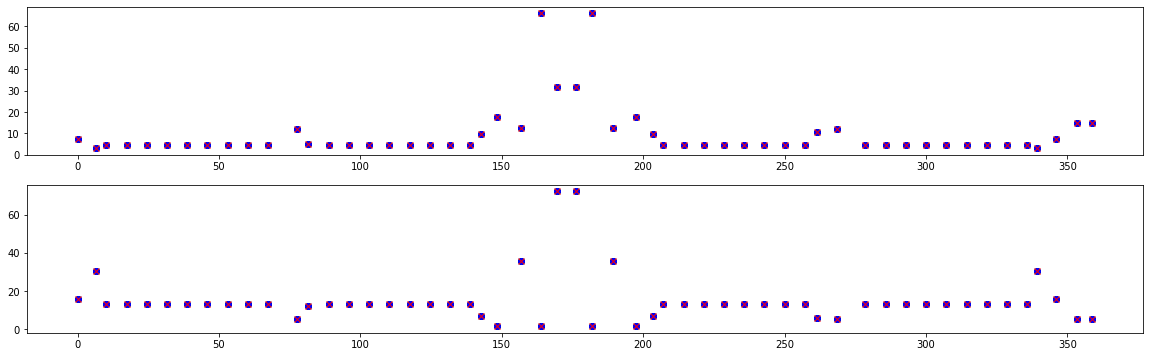

tensor(8.737e-02, dtype=torch.float64)
tensor(5.784e-03, dtype=torch.float64)
tensor(4.380e-03, dtype=torch.float64)

tensor(3.963e-02, dtype=torch.float64)
tensor(1.460e-03, dtype=torch.float64)
tensor(7.761e-03, dtype=torch.float64)



In [12]:
# Estimate twiss from phase

twiss = Twiss(model, table, limit=4)
twiss.phase_virtual()
twiss.get_twiss_from_phase()
mask_x = twiss.filter_twiss(plane='x', phase={'use': True, 'threshold': 10.0}, model={'use': True, 'threshold': 0.5}, value={'use': False, 'threshold': 0.5}, sigma={'use': False, 'threshold': 0.25}, limit={'use': True, 'threshold': 5.0})
mask_y = twiss.filter_twiss(plane='y', phase={'use': True, 'threshold': 10.0}, model={'use': True, 'threshold': 0.5}, value={'use': False, 'threshold': 0.5}, sigma={'use': False, 'threshold': 0.25}, limit={'use': True, 'threshold': 5.0})
twiss.process_twiss(plane='x', mask=mask_x, weight=True)
twiss.process_twiss(plane='y', mask=mask_y, weight=True)

plt.figure(figsize=(20, 3*2))

ax = plt.subplot(211)
ax.scatter(model.time[model.monitor_index].cpu().numpy(), model.bx[model.monitor_index].cpu().numpy(), marker='o', color='black')
ax.scatter(model.time[model.monitor_index].cpu().numpy(), cs_bx[model.monitor_index].cpu().numpy(), marker='o', color='blue')
ax.errorbar(model.time[model.monitor_index].cpu().numpy(), twiss.bx[model.monitor_index].cpu().numpy(), yerr=twiss.sigma_bx[model.monitor_index].cpu().numpy(), fmt=' ', marker='x', color='red')

ax = plt.subplot(212)
ax.scatter(model.time[model.monitor_index].cpu().numpy(), model.by[model.monitor_index].cpu().numpy(), marker='o', color='black')
ax.scatter(model.time[model.monitor_index].cpu().numpy(), cs_by[model.monitor_index].cpu().numpy(), marker='o', color='blue')
ax.errorbar(model.time[model.monitor_index].cpu().numpy(), twiss.by[model.monitor_index].cpu().numpy(), yerr=twiss.sigma_by[model.monitor_index].cpu().numpy(), fmt=' ', marker='x', color='red')

plt.show()

error_x_2 = (cs_bx[model.monitor_index] - twiss.bx[model.monitor_index]).abs().sum()
error_y_2 = (cs_by[model.monitor_index] - twiss.by[model.monitor_index]).abs().sum()

print(error_x)
print(error_x_1)
print(error_x_2)
print()

print(error_y)
print(error_y_1)
print(error_y_2)
print()

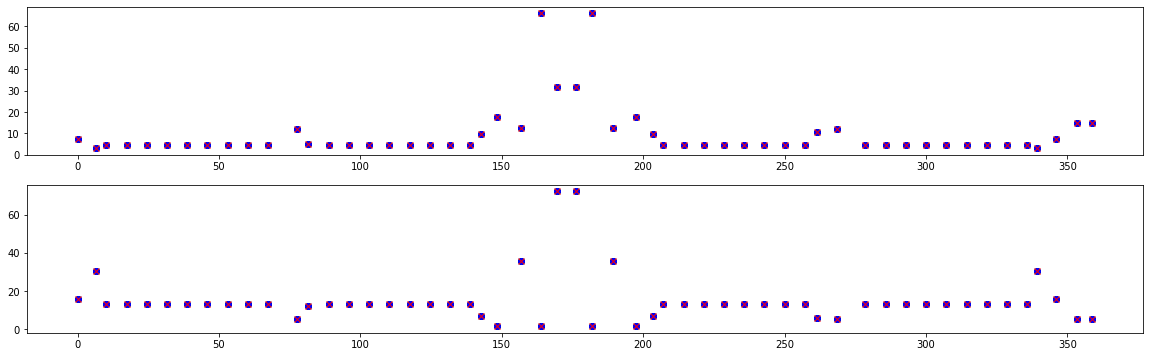

tensor(8.737e-02, dtype=torch.float64)
tensor(5.784e-03, dtype=torch.float64)
tensor(4.380e-03, dtype=torch.float64)
tensor(1.449e-04, dtype=torch.float64)

tensor(3.963e-02, dtype=torch.float64)
tensor(1.460e-03, dtype=torch.float64)
tensor(7.761e-03, dtype=torch.float64)
tensor(1.451e-04, dtype=torch.float64)



In [13]:
# Estimate twiss from amplitude (corrected action)

twiss.get_action(bx=twiss.bx[model.monitor_index], by=twiss.by[model.monitor_index], sigma_bx=twiss.sigma_bx[model.monitor_index], sigma_by=twiss.sigma_by[model.monitor_index])
twiss.get_twiss_from_amplitude()

plt.figure(figsize=(20, 3*2))

ax = plt.subplot(211)
ax.scatter(model.time[model.monitor_index].cpu().numpy(), model.bx[model.monitor_index].cpu().numpy(), marker='o', color='black')
ax.scatter(model.time[model.monitor_index].cpu().numpy(), cs_bx[model.monitor_index].cpu().numpy(), marker='o', color='blue')
ax.errorbar(model.time[model.monitor_index].cpu().numpy(), twiss.data_amplitude['bx'].cpu().numpy(), yerr=twiss.data_amplitude['sigma_bx'].cpu().numpy(), fmt=' ', marker='x', color='red')

ax = plt.subplot(212)
ax.scatter(model.time[model.monitor_index].cpu().numpy(), model.by[model.monitor_index].cpu().numpy(), marker='o', color='black')
ax.scatter(model.time[model.monitor_index].cpu().numpy(), cs_by[model.monitor_index].cpu().numpy(), marker='o', color='blue')
ax.errorbar(model.time[model.monitor_index].cpu().numpy(), twiss.data_amplitude['by'].cpu().numpy(), yerr=twiss.data_amplitude['sigma_by'].cpu().numpy(), fmt=' ', marker='x', color='red')

plt.show()

error_x_3 = (cs_bx[model.monitor_index] - twiss.data_amplitude['bx']).abs().sum()
error_y_3 = (cs_by[model.monitor_index] - twiss.data_amplitude['by']).abs().sum()

print(error_x)
print(error_x_1)
print(error_x_2)
print(error_x_3)
print()

print(error_y)
print(error_y_1)
print(error_y_2)
print(error_y_3)
print()

In [14]:
%%time

# Estimate twiss from invariant fit (use first 256 turns and 512 random samples)

from harmonica.parameterization import parametric_normal
data = twiss.get_twiss_from_data(1,                # -- first turn
                                 256,              # -- total number of turns, orbits are computed for (start, start + total)
                                 parametric_normal,# -- normalization
                                 model.matrix,     # -- transport matrix generator
                                 twiss=None,       # -- initial twiss for each location or None (use model values)
                                 method='pair',    # -- momenta computation method
                                 limit=1,          # -- range limit or direction/shift
                                 product=True,     # -- flag to use product objective
                                 jacobian=False,   # -- flag to use objective jacobian
                                 count=128,        # -- number of samples
                                 fraction=0.75,    # -- sample length fraction
                                 ix=None,          # -- ix invariant value
                                 iy=None,          # -- iy invariant value  (both should present for fixed fit)
                                 n_jobs=2,         # -- number of parallel jobs (loop over samples)
                                 verbose=False)    # -- verbose flag
print(data.shape)

torch.Size([54, 2, 10, 128])
CPU times: user 1min 46s, sys: 2.25 s, total: 1min 48s
Wall time: 6min 20s


In [15]:
# Process fitted invariants

ix = data[:, 0, 0]
iy = data[:, 0, 1]

sigma_ix = data[:, 1, 0]
sigma_iy = data[:, 1, 1]

invariant = twiss.get_invariant(ix, iy, sigma_ix, sigma_iy)

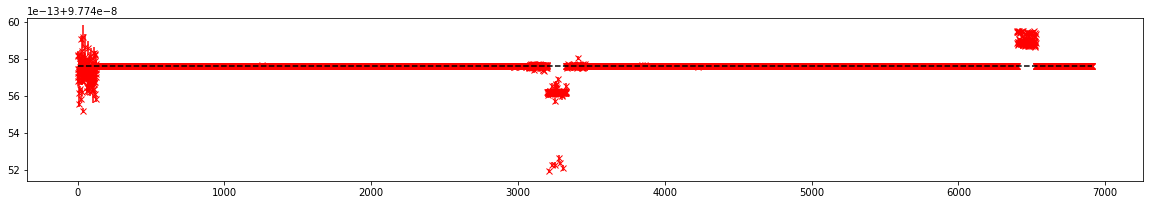

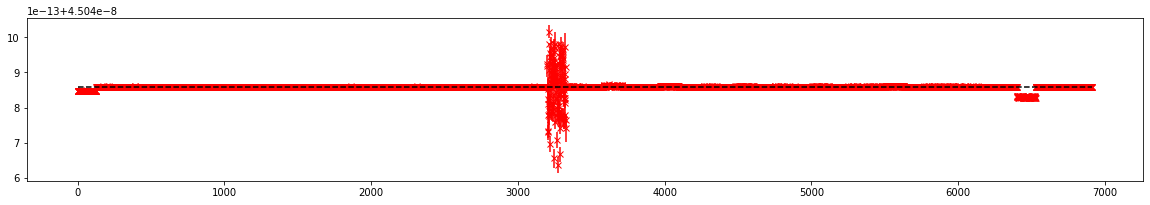

In [16]:
# Plot invariants for each sample in each signal

plt.figure(figsize=(20, 3))
plt.errorbar(range(54*128), ix.flatten().cpu().numpy(), yerr=sigma_ix.flatten().cpu().numpy(), fmt=' ', color='red', marker='x', zorder=0)
plt.hlines(action_x, 0, 54*128, linestyles='dashed', color='black',  zorder=1)
plt.show()

plt.figure(figsize=(20, 3))
plt.errorbar(range(54*128), iy.flatten().cpu().numpy(), yerr=sigma_iy.flatten().cpu().numpy(), fmt=' ', color='red', marker='x', zorder=0)
plt.hlines(action_y, 0, 54*128, linestyles='dashed', color='black',  zorder=1)
plt.show()

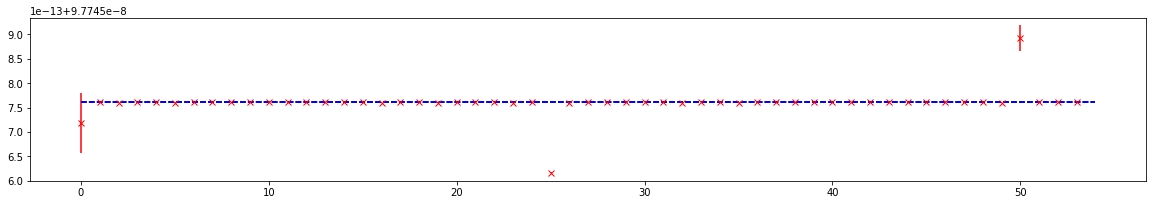

tensor(9.775e-08, dtype=torch.float64)
tensor(9.775e-08, dtype=torch.float64)
tensor(1.836e-16, dtype=torch.float64)



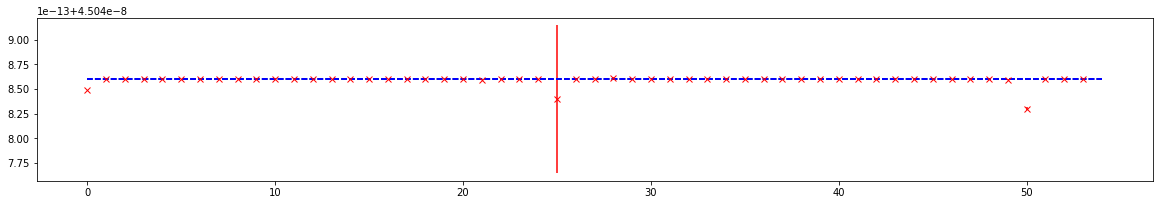

tensor(4.504e-08, dtype=torch.float64)
tensor(4.504e-08, dtype=torch.float64)
tensor(5.144e-17, dtype=torch.float64)



In [17]:
# Plot invariants for each signal

plt.figure(figsize=(20, 3))
plt.errorbar(range(54), invariant['ix_center'].flatten().cpu().numpy(), yerr=invariant['ix_spread'].flatten().cpu().numpy(), fmt=' ', color='red', marker='x')
plt.hlines(action_x, 0, 54, linestyles='dashed', color='black')
plt.hlines([invariant['ix_value'] - invariant['ix_error'], invariant['ix_value'], invariant['ix_value'] + invariant['ix_error']], 0, 54, linestyles='dashed', color='blue')
plt.show()

print(action_x)
print(invariant['ix_value'])
print(invariant['ix_error'])
print()

plt.figure(figsize=(20, 3))
plt.errorbar(range(54), invariant['iy_center'].flatten().cpu().numpy(), yerr=invariant['iy_spread'].flatten().cpu().numpy(), fmt=' ', color='red', marker='x')
plt.hlines(action_y, 0, 54, linestyles='dashed', color='black')
plt.hlines([invariant['iy_value'] - invariant['iy_error'], invariant['iy_value'], invariant['iy_value'] + invariant['iy_error']], 0, 54, linestyles='dashed', color='blue')
plt.show()

print(action_y)
print(invariant['iy_value'])
print(invariant['iy_error'])
print()

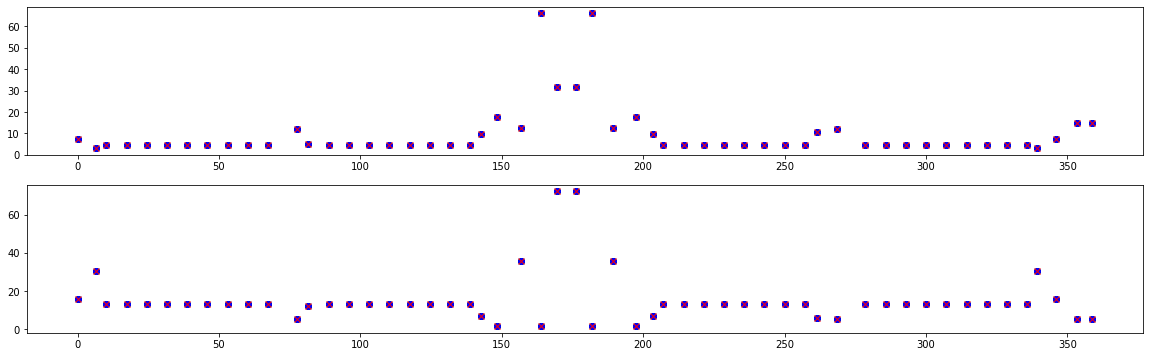

tensor(8.737e-02, dtype=torch.float64)
tensor(5.784e-03, dtype=torch.float64)
tensor(4.380e-03, dtype=torch.float64)
tensor(1.449e-04, dtype=torch.float64)
tensor(8.398e-05, dtype=torch.float64)

tensor(3.963e-02, dtype=torch.float64)
tensor(1.460e-03, dtype=torch.float64)
tensor(7.761e-03, dtype=torch.float64)
tensor(1.451e-04, dtype=torch.float64)
tensor(2.525e-04, dtype=torch.float64)



In [18]:
# Process matrix elements

mask = invariant['ix_mask']*invariant['sx_mask']*invariant['iy_mask']*invariant['sy_mask']

value_n11 = data[:, 0, 2]
error_n11 = data[:, 1, 2]

value_n33 = data[:, 0, 3]
error_n33 = data[:, 1, 3]

value_n21 = data[:, 0, 4]
error_n21 = data[:, 1, 4]

value_n43 = data[:, 0, 5]
error_n43 = data[:, 1, 5]

value_n13 = data[:, 0, 6]
error_n13 = data[:, 1, 6]

value_n31 = data[:, 0, 7]
error_n31 = data[:, 1, 7]

value_n14 = data[:, 0, 8]
error_n14 = data[:, 1, 8]

value_n41 = data[:, 0, 9]
error_n41 = data[:, 1, 9]

value_n11, error_n11 = twiss.process(value_n11, error_n11, mask=mask)
value_n33, error_n33 = twiss.process(value_n33, error_n33, mask=mask)
value_n21, error_n21 = twiss.process(value_n21, error_n21, mask=mask)
value_n43, error_n43 = twiss.process(value_n43, error_n43, mask=mask)
value_n13, error_n13 = twiss.process(value_n13, error_n13, mask=mask)
value_n31, error_n31 = twiss.process(value_n31, error_n31, mask=mask)
value_n14, error_n14 = twiss.process(value_n14, error_n14, mask=mask)
value_n41, error_n41 = twiss.process(value_n41, error_n41, mask=mask)

from harmonica.parameterization import parametric_normal
from harmonica.parameterization import normal_to_wolski
from harmonica.parameterization import wolski_to_cs

value = torch.stack([value_n11, value_n33, value_n21, value_n43, value_n13, value_n31, value_n14, value_n41]).T
error = torch.stack([error_n11, error_n33, error_n21, error_n43, error_n13, error_n31, error_n14, error_n41]).T

cs_value, cs_error = [], []

for value_loc, error_loc in zip(value, error):
    table = value_loc.reshape(-1, 1) + error_loc.reshape(-1, 1)*torch.randn(1024, dtype=dtype, device=device)
    table = torch.stack([parametric_normal(*free) for free in table.T])
    table = normal_to_wolski(table)
    table = torch.stack([wolski_to_cs(w) for w in table]).T
    cs_value.append(table.mean(-1))
    cs_error.append(table.std(-1))
    
cs_value = torch.stack(cs_value)
cs_error = torch.stack(cs_error)

value_ax, value_bx, value_ay, value_by = cs_value.T
error_ax, error_bx, error_ay, error_by = cs_error.T

plt.figure(figsize=(20, 3*2))

ax = plt.subplot(211)
ax.scatter(model.time[model.monitor_index].cpu().numpy(), model.bx[model.monitor_index].cpu().numpy(), marker='o', color='black')
ax.scatter(model.time[model.monitor_index].cpu().numpy(), cs_bx[model.monitor_index].cpu().numpy(), marker='o', color='blue')
ax.errorbar(model.time[model.monitor_index].cpu().numpy(), value_bx.cpu().numpy(), yerr=error_bx.cpu().numpy(), fmt=' ', marker='x', color='red')

ax = plt.subplot(212)
ax.scatter(model.time[model.monitor_index].cpu().numpy(), model.by[model.monitor_index].cpu().numpy(), marker='o', color='black')
ax.scatter(model.time[model.monitor_index].cpu().numpy(), cs_by[model.monitor_index].cpu().numpy(), marker='o', color='blue')
ax.errorbar(model.time[model.monitor_index].cpu().numpy(), value_by.cpu().numpy(), yerr=error_by.cpu().numpy(), fmt=' ', marker='x', color='red')

plt.show()

error_x_4 = (cs_bx[model.monitor_index] - value_bx).abs().sum()
error_y_4 = (cs_by[model.monitor_index] - value_by).abs().sum()

print(error_x)
print(error_x_1)
print(error_x_2)
print(error_x_3)
print(error_x_4)
print()

print(error_y)
print(error_y_1)
print(error_y_2)
print(error_y_3)
print(error_y_4)
print()

In [19]:
# Compute normalization matrices

from harmonica.parameterization import parametric_normal

values = torch.stack([value_n11, value_n33, value_n21, value_n43, value_n13, value_n31, value_n14, value_n41]).T
normal = torch.stack([parametric_normal(*value) for value in values])

# Set monitor matrices

twiss.normal[model.monitor_index] = normal.clone()

In [20]:
# Twiss at virtual locations (from virtual orbits)

from harmonica.parameterization import parametric_normal
data = twiss.get_twiss_from_data(1,
                                 256,
                                 parametric_normal,
                                 model.matrix,
                                 twiss=None,
                                 method='lstsq',
                                 limit=2,
                                 phony=True,
                                 product=True,
                                 jacobian=False,
                                 count=128,
                                 fraction=0.75,
                                 ix=invariant['ix_value'],
                                 iy=invariant['iy_value'],
                                 sigma=1.0E-3,
                                 n_jobs=12,
                                 verbose=False)
print(data.shape)
print(model.virtual_count)

torch.Size([5, 2, 8, 128])
5


In [21]:
# Process twiss

value_n11 = data[:, 0, 0]
error_n11 = data[:, 1, 0]

value_n33 = data[:, 0, 1]
error_n33 = data[:, 1, 1]

value_n21 = data[:, 0, 2]
error_n21 = data[:, 1, 2]

value_n43 = data[:, 0, 3]
error_n43 = data[:, 1, 3]

value_n13 = data[:, 0, 4]
error_n13 = data[:, 1, 4]

value_n31 = data[:, 0, 5]
error_n31 = data[:, 1, 5]

value_n14 = data[:, 0, 6]
error_n14 = data[:, 1, 6]

value_n41 = data[:, 0, 7]
error_n41 = data[:, 1, 7]

value_n11, error_n11 = twiss.process(value_n11, error_n11)
value_n33, error_n33 = twiss.process(value_n33, error_n33)
value_n21, error_n21 = twiss.process(value_n21, error_n21)
value_n43, error_n43 = twiss.process(value_n43, error_n43)
value_n13, error_n13 = twiss.process(value_n13, error_n13)
value_n31, error_n31 = twiss.process(value_n31, error_n31)
value_n14, error_n14 = twiss.process(value_n14, error_n14)
value_n41, error_n41 = twiss.process(value_n41, error_n41)

In [22]:
# Compute normalization matrices

from harmonica.parameterization import parametric_normal

values = torch.stack([value_n11, value_n33, value_n21, value_n43, value_n13, value_n31, value_n14, value_n41]).T
normal = torch.stack([parametric_normal(*value) for value in values])

# Set virtual matrices

twiss.normal[model.virtual_index] = normal.clone()

In [23]:
# Shift phase

twiss.fx = twiss.fx - twiss.fx[0]
twiss.fy = twiss.fy - twiss.fy[0]

In [24]:
# Save

model.model = 'coupled'
twiss.save_model('config.yaml')

In [25]:
# Load

result = Model('config.yaml', model='coupled', dtype=dtype, device=device)

In [26]:
# Test

result.make_transport(error=False, exact=False)
result.make_twiss()

print(result.out_tune_fractional)
print(model.out_tune_fractional)

tensor([5.369e-01, 5.768e-01], dtype=torch.float64)
tensor([5.369e-01, 5.768e-01], dtype=torch.float64)


In [27]:
# Test

print(model.matrix_transport(0, model.size - 1))
print(result.matrix_transport(0, model.size - 1))

tensor([[-8.176e-01, -1.715e+00, -3.432e-06,  1.621e-04],
        [ 4.490e-02, -1.129e+00,  4.467e-07,  3.117e-05],
        [-3.742e-05,  1.883e-04, -1.189e+00, -7.355e+00],
        [ 1.492e-06, -2.712e-06,  4.179e-02, -5.823e-01]], dtype=torch.float64)
tensor([[-8.176e-01, -1.715e+00, -4.654e-06,  1.619e-04],
        [ 4.490e-02, -1.129e+00, -1.087e-07,  3.249e-05],
        [-4.243e-05,  1.884e-04, -1.189e+00, -7.355e+00],
        [ 1.240e-06, -2.359e-06,  4.179e-02, -5.823e-01]], dtype=torch.float64)
